In [1]:
import ccxt
import pandas as pd
import numpy as np
import ta
import joblib
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')
print("Libraries loaded!")

Libraries loaded!


In [2]:
exchange = ccxt.binance()

def fetch_fresh_data(symbol, limit=500):
    ohlcv = exchange.fetch_ohlcv(symbol, '1h', limit=limit)
    df = pd.DataFrame(ohlcv, columns=['timestamp','open','high','low','close','volume'])
    df['timestamp'] = pd.to_datetime(df['timestamp'], unit='ms')
    df = df.sort_values('timestamp').reset_index(drop=True)
    return df

btc_live = fetch_fresh_data('BTC/USDT', limit=500)
eth_live = fetch_fresh_data('ETH/USDT', limit=500)

print(f"BTC fresh data: {btc_live.shape}")
print(f"  From: {btc_live['timestamp'].iloc[0]}")
print(f"  To:   {btc_live['timestamp'].iloc[-1]}")
print(f"\nETH fresh data: {eth_live.shape}")
print(f"  From: {eth_live['timestamp'].iloc[0]}")
print(f"  To:   {eth_live['timestamp'].iloc[-1]}")

BTC fresh data: (500, 6)
  From: 2026-03-17 16:00:00
  To:   2026-04-07 11:00:00

ETH fresh data: (500, 6)
  From: 2026-03-17 16:00:00
  To:   2026-04-07 11:00:00


In [3]:
def add_all_features(df):
    df['ma20']    = df['close'].rolling(20).mean()
    df['ma50']    = df['close'].rolling(50).mean()
    df['ma200']   = df['close'].rolling(200).mean()
    df['rsi']     = ta.momentum.RSIIndicator(df['close']).rsi()
    df['returns'] = df['close'].pct_change()
    df['vol_20']  = df['close'].rolling(20).std()
    
    macd = ta.trend.MACD(df['close'])
    df['macd']        = macd.macd()
    df['macd_signal'] = macd.macd_signal()
    df['macd_diff']   = macd.macd_diff()
    
    bb = ta.volatility.BollingerBands(df['close'])
    df['bb_high']  = bb.bollinger_hband()
    df['bb_low']   = bb.bollinger_lband()
    df['bb_mid']   = bb.bollinger_mavg()
    df['bb_width'] = (df['bb_high'] - df['bb_low']) / df['bb_mid']
    df['bb_pct']   = (df['close'] - df['bb_low']) / (df['bb_high'] - df['bb_low'])
    
    df['atr'] = ta.volatility.AverageTrueRange(
                    df['high'], df['low'], df['close']).average_true_range()
    
    stoch = ta.momentum.StochRSIIndicator(df['close'])
    df['stoch_rsi']   = stoch.stochrsi()
    df['stoch_rsi_k'] = stoch.stochrsi_k()
    df['stoch_rsi_d'] = stoch.stochrsi_d()
    
    df['volume_ma20']  = df['volume'].rolling(20).mean()
    df['volume_ratio'] = df['volume'] / df['volume_ma20']
    df['dist_ma200']   = (df['close'] - df['ma200']) / df['ma200']
    df['dist_ma50']    = (df['close'] - df['ma50'])  / df['ma50']
    df['hour']         = df['timestamp'].dt.hour
    df['day_of_week']  = df['timestamp'].dt.dayofweek
    
    for lag in [1, 2, 3, 6, 12, 24]:
        df[f'close_lag_{lag}']   = df['close'].shift(lag)
        df[f'returns_lag_{lag}'] = df['returns'].shift(lag)
    
    df = df.dropna().reset_index(drop=True)
    return df

# ← APPLY THE FUNCTION
btc_live = add_all_features(btc_live)
eth_live = add_all_features(eth_live)

print(f"BTC after features: {btc_live.shape}")
print(f"ETH after features: {eth_live.shape}")
print(f"Columns: {list(btc_live.columns)}")

BTC after features: (301, 42)
ETH after features: (301, 42)
Columns: ['timestamp', 'open', 'high', 'low', 'close', 'volume', 'ma20', 'ma50', 'ma200', 'rsi', 'returns', 'vol_20', 'macd', 'macd_signal', 'macd_diff', 'bb_high', 'bb_low', 'bb_mid', 'bb_width', 'bb_pct', 'atr', 'stoch_rsi', 'stoch_rsi_k', 'stoch_rsi_d', 'volume_ma20', 'volume_ratio', 'dist_ma200', 'dist_ma50', 'hour', 'day_of_week', 'close_lag_1', 'returns_lag_1', 'close_lag_2', 'returns_lag_2', 'close_lag_3', 'returns_lag_3', 'close_lag_6', 'returns_lag_6', 'close_lag_12', 'returns_lag_12', 'close_lag_24', 'returns_lag_24']


In [4]:
# Load best models
best_btc   = joblib.load('../data/models/best_btc.joblib')   # Neural Network
best_eth   = joblib.load('../data/models/best_eth.joblib')   # XGBoost
btc_scaler = joblib.load('../data/models/best_btc_scaler.joblib')

# Use exact features from scaler
FEATURE_COLS = list(btc_scaler.feature_names_in_)
print(f"Features: {len(FEATURE_COLS)}")

LABEL_MAP = {0: 'SELL', 1: 'HOLD', 2: 'BUY'}

# BTC — Neural Network needs scaled features
btc_X    = btc_live[FEATURE_COLS].fillna(0)
btc_X_sc = btc_scaler.transform(btc_X)
btc_live['signal']       = best_btc.predict(btc_X_sc)
btc_live['signal_label'] = btc_live['signal'].map(LABEL_MAP)

# ETH — XGBoost uses raw features
eth_X = eth_live[FEATURE_COLS].fillna(0)
eth_live['signal']       = best_eth.predict(eth_X)
eth_live['signal_label'] = eth_live['signal'].map(LABEL_MAP)

print("BTC signal distribution on LIVE data:")
print(btc_live['signal_label'].value_counts())
print(f"\nLatest BTC signal: {btc_live['signal_label'].iloc[-1]}")
print(f"Latest BTC price:  ${btc_live['close'].iloc[-1]:,.2f}")

print("\nETH signal distribution on LIVE data:")
print(eth_live['signal_label'].value_counts())
print(f"\nLatest ETH signal: {eth_live['signal_label'].iloc[-1]}")
print(f"Latest ETH price:  ${eth_live['close'].iloc[-1]:,.2f}")

Features: 35
BTC signal distribution on LIVE data:
signal_label
HOLD    142
SELL     86
BUY      73
Name: count, dtype: int64

Latest BTC signal: SELL
Latest BTC price:  $68,323.82

ETH signal distribution on LIVE data:
signal_label
HOLD    209
SELL     67
BUY      25
Name: count, dtype: int64

Latest ETH signal: SELL
Latest ETH price:  $2,088.90


In [5]:
def backtest_live(df, symbol, initial_capital=10000):
    capital = initial_capital
    position = 0
    portfolio_values = []
    trades = []

    for i in range(len(df)):
        price = df['close'].iloc[i]
        signal = df['signal'].iloc[i]
        timestamp = df['timestamp'].iloc[i]

        if signal == 2 and capital > 0:
            position = capital / price
            capital = 0
            trades.append({'timestamp': timestamp, 'type': 'BUY', 'price': price})

        elif signal == 0 and position > 0:
            capital = position * price
            trades.append({'timestamp': timestamp, 'type': 'SELL', 'price': price})
            position = 0

        portfolio_value = capital + (position * price)
        portfolio_values.append({
            'timestamp': timestamp,
            'portfolio_value': portfolio_value,
            'price': price
        })

    final_price = df['close'].iloc[-1]
    final_value = capital + (position * final_price)
    roi = (final_value - initial_capital) / initial_capital * 100

    portfolio_df = pd.DataFrame(portfolio_values)
    portfolio_df['peak'] = portfolio_df['portfolio_value'].cummax()
    portfolio_df['drawdown'] = (portfolio_df['portfolio_value'] - portfolio_df['peak']) / portfolio_df['peak'] * 100

    trades_df = pd.DataFrame(trades) if trades else pd.DataFrame()
    sell_trades = trades_df[trades_df['type'] == 'SELL'] if len(trades_df) > 0 else pd.DataFrame()

    bah_roi = (df['close'].iloc[-1] - df['close'].iloc[0]) / df['close'].iloc[0] * 100

    print(f"\n{'='*55}")
    print(f"{symbol} LIVE DATA Test Results (truly unseen data)")
    print(f"{'='*55}")
    print(f"Period:          {df['timestamp'].iloc[0]} → {df['timestamp'].iloc[-1]}")
    print(f"Initial capital: $10,000.00")
    print(f"Final value:     ${final_value:,.2f}")
    print(f"ROI:             {roi:.2f}%")
    print(f"Max Drawdown:    {portfolio_df['drawdown'].min():.2f}%")
    print(f"Total trades:    {len(sell_trades)}")
    print(f"Buy & Hold ROI:  {bah_roi:.2f}%")
    print(f"vs Buy & Hold:   {roi - bah_roi:+.2f}%")
    print(f"{'='*55}")

    return portfolio_df

btc_live_portfolio = backtest_live(btc_live, 'BTC')
eth_live_portfolio = backtest_live(eth_live, 'ETH')


BTC LIVE DATA Test Results (truly unseen data)
Period:          2026-03-25 23:00:00 → 2026-04-07 11:00:00
Initial capital: $10,000.00
Final value:     $9,722.67
ROI:             -2.77%
Max Drawdown:    -5.53%
Total trades:    21
Buy & Hold ROI:  -4.22%
vs Buy & Hold:   +1.45%

ETH LIVE DATA Test Results (truly unseen data)
Period:          2026-03-25 23:00:00 → 2026-04-07 11:00:00
Initial capital: $10,000.00
Final value:     $9,841.24
ROI:             -1.59%
Max Drawdown:    -4.31%
Total trades:    14
Buy & Hold ROI:  -3.69%
vs Buy & Hold:   +2.11%


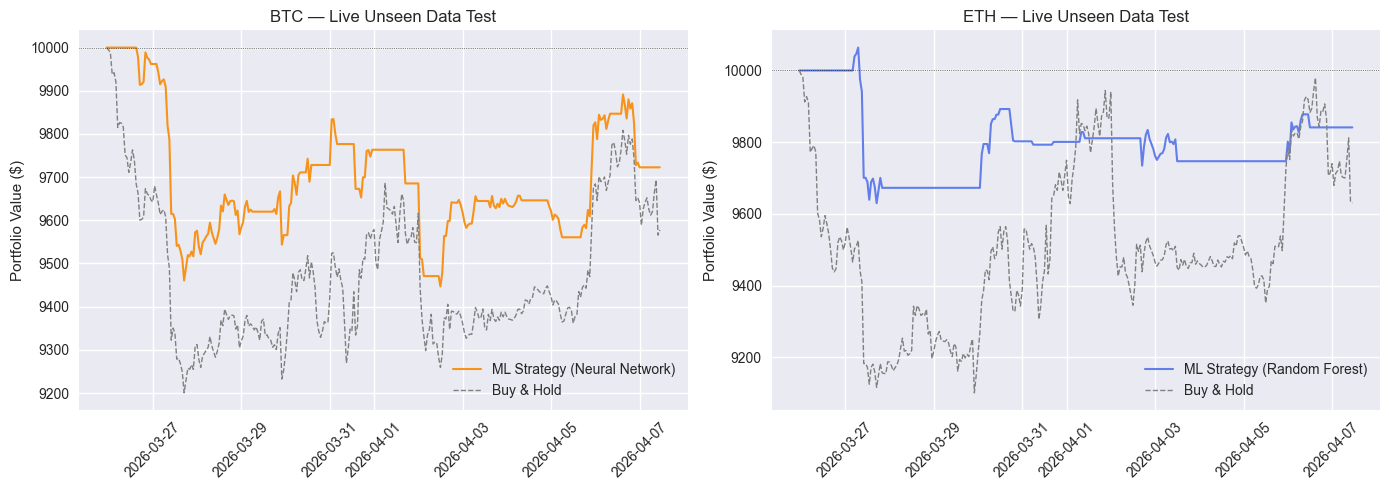

Chart saved!


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (portfolio_df, df, symbol, color, model) in zip(axes, [
    (btc_live_portfolio, btc_live, 'BTC', '#F7931A', 'Neural Network'),
    (eth_live_portfolio, eth_live, 'ETH', '#627EEA', 'Random Forest')
]):
    ax.plot(portfolio_df['timestamp'],
            portfolio_df['portfolio_value'],
            color=color, linewidth=1.5, label=f'ML Strategy ({model})')

    bah = 10000 / df['close'].iloc[0] * portfolio_df['price']
    ax.plot(portfolio_df['timestamp'], bah,
            color='gray', linestyle='--', linewidth=1, label='Buy & Hold')

    ax.axhline(y=10000, color='black', linewidth=0.5, linestyle=':')
    ax.set_title(f'{symbol} — Live Unseen Data Test')
    ax.set_ylabel('Portfolio Value ($)')
    ax.legend()
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../docs/diagrams/live_test_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")